In [1]:
import sys
sys.path.append('..')

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
# Olist order_status is a natural funnel
# created → approved → invoiced → processing → shipped → delivered
status_counts = con.execute("""
    SELECT order_status, COUNT(*) AS orders
    FROM orders
    GROUP BY order_status
    ORDER BY orders DESC
""").df()

print("All order statuses:")
print(status_counts)

All order statuses:
  order_status  orders
0    delivered   96478
1      shipped    1107
2     canceled     625
3  unavailable     609
4     invoiced     314
5   processing     301
6      created       5
7     approved       2


In [3]:
# Define funnel stages in order
# Each stage = orders that reached AT LEAST this status
funnel_stages = [
    ("Order created",    ["created","approved","invoiced","processing","shipped","delivered"]),
    ("Order approved",   ["approved","invoiced","processing","shipped","delivered"]),
    ("Invoiced",         ["invoiced","processing","shipped","delivered"]),
    ("Processing",       ["processing","shipped","delivered"]),
    ("Shipped",          ["shipped","delivered"]),
    ("Delivered",        ["delivered"]),
]

total_orders = status_counts["orders"].sum()

funnel_data = []
for stage_name, included_statuses in funnel_stages:
    count = status_counts[
        status_counts["order_status"].isin(included_statuses)
    ]["orders"].sum()
    funnel_data.append({
        "stage":        stage_name,
        "orders":       int(count),
        "pct_of_total": round(count / total_orders * 100, 2),
    })

funnel_df = pd.DataFrame(funnel_data)

# Add drop-off columns
funnel_df["drop_off_abs"] = funnel_df["orders"].diff().abs().fillna(0).astype(int)
funnel_df["drop_off_pct"] = (
    funnel_df["orders"].pct_change().abs() * 100
).fillna(0).round(2)

print(funnel_df.to_string(index=False))

         stage  orders  pct_of_total  drop_off_abs  drop_off_pct
 Order created   98207         98.76             0          0.00
Order approved   98202         98.75             5          0.01
      Invoiced   98200         98.75             2          0.00
    Processing   97886         98.44           314          0.32
       Shipped   97585         98.13           301          0.31
     Delivered   96478         97.02          1107          1.13


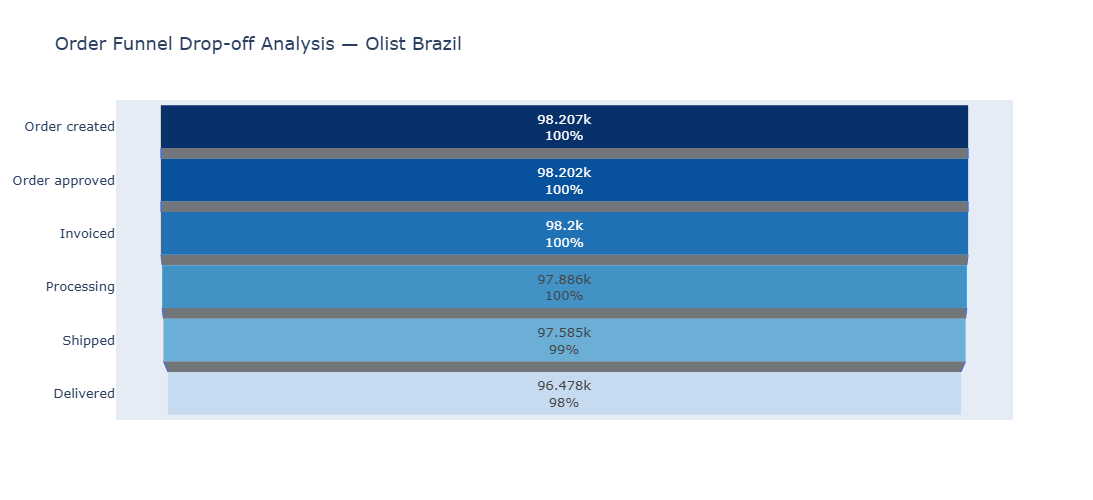

In [4]:
fig1 = go.Figure(go.Funnel(
    y=funnel_df["stage"],
    x=funnel_df["orders"],
    textposition="inside",
    textinfo="value+percent initial",
    marker=dict(
        color=["#08306b","#08519c","#2171b5","#4292c6","#6baed6","#c6dbef"]
    ),
    connector=dict(line=dict(color="royalblue", width=1))
))

fig1.update_layout(
    title="Order Funnel Drop-off Analysis — Olist Brazil",
    height=500,
    font=dict(size=13)
)
fig1.show()

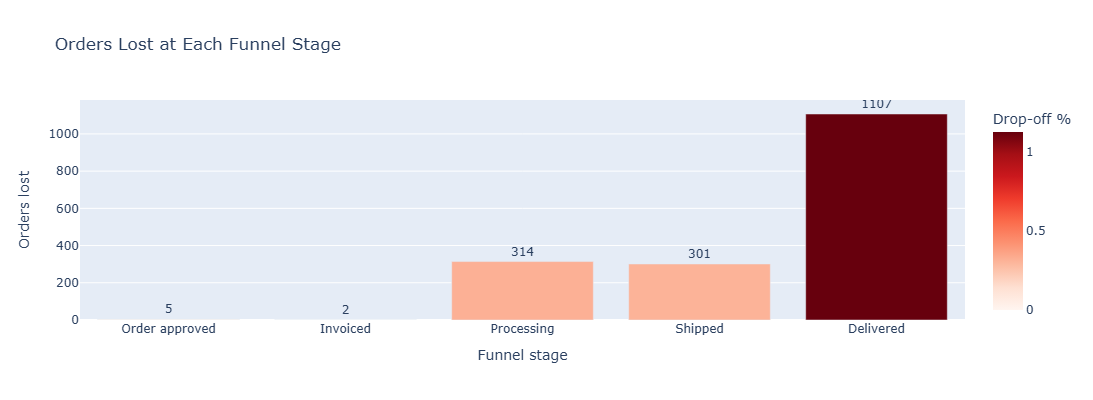

In [5]:
# Show only stages with actual drop-off
drop_df = funnel_df[funnel_df["drop_off_abs"] > 0].copy()

fig2 = px.bar(
    drop_df,
    x="stage",
    y="drop_off_abs",
    text="drop_off_abs",
    color="drop_off_pct",
    color_continuous_scale="Reds",
    title="Orders Lost at Each Funnel Stage",
    labels={"drop_off_abs": "Orders lost",
            "stage": "Funnel stage",
            "drop_off_pct": "Drop-off %"}
)
fig2.update_traces(textposition="outside")
fig2.update_layout(height=400)
fig2.show()

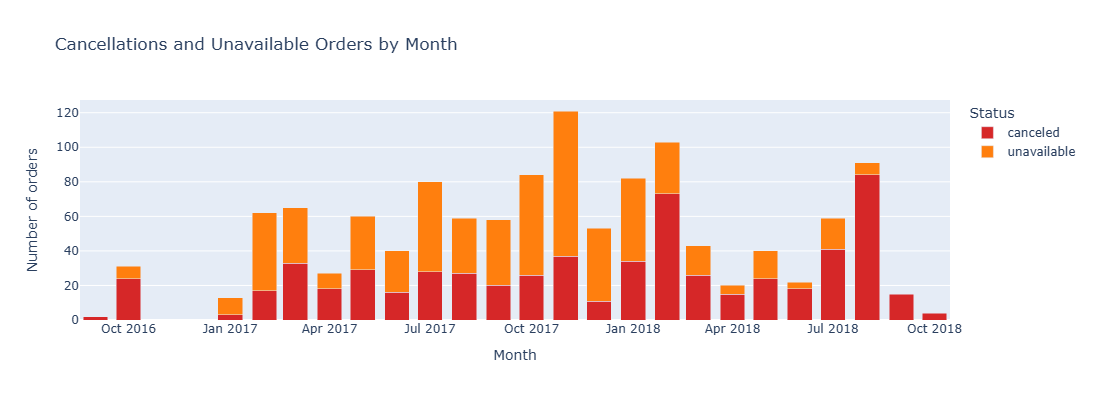

In [6]:
# When do cancellations happen — by month
cancellations = con.execute("""
    SELECT
        DATE_TRUNC('month', order_purchase_timestamp::TIMESTAMP)::DATE AS month,
        order_status,
        COUNT(*) AS orders
    FROM orders
    WHERE order_status IN ('canceled', 'unavailable')
    GROUP BY month, order_status
    ORDER BY month
""").df()

cancellations["month"] = pd.to_datetime(cancellations["month"])

fig3 = px.bar(
    cancellations,
    x="month",
    y="orders",
    color="order_status",
    barmode="stack",
    title="Cancellations and Unavailable Orders by Month",
    labels={"orders": "Number of orders",
            "month": "Month",
            "order_status": "Status"},
    color_discrete_map={"canceled": "#d62728", "unavailable": "#ff7f0e"}
)
fig3.update_layout(height=400)
fig3.show()

In [7]:
payment_status = con.execute("""
    SELECT
        p.payment_type,
        o.order_status,
        COUNT(*) AS orders
    FROM orders o
    JOIN payments p USING (order_id)
    GROUP BY p.payment_type, o.order_status
""").df()

# Focus on delivered vs canceled
piv = payment_status[
    payment_status["order_status"].isin(["delivered","canceled"])
].pivot_table(index="payment_type", columns="order_status", values="orders", fill_value=0)

piv["cancel_rate_pct"] = (
    piv["canceled"] / (piv["canceled"] + piv["delivered"]) * 100
).round(2)

print("Cancellation rate by payment method:")
print(piv.sort_values("cancel_rate_pct", ascending=False))

Cancellation rate by payment method:
order_status  canceled  delivered  cancel_rate_pct
payment_type                                      
not_defined        3.0        0.0           100.00
voucher          115.0     5493.0             2.05
credit_card      444.0    74586.0             0.59
boleto            95.0    19191.0             0.49
debit_card         7.0     1486.0             0.47


In [8]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

fig1.write_html("../docs/screenshots/04_funnel_chart.html")
fig2.write_html("../docs/screenshots/04_funnel_dropoff.html")
fig3.write_html("../docs/screenshots/04_cancellations.html")

funnel_df.to_csv("../data/processed/04_funnel_analysis.csv", index=False)

print("FUNNEL ANALYSIS SUMMARY")
print(f"Total orders      : {total_orders:,}")
print(f"Delivered         : {funnel_df.iloc[-1]['orders']:,} ({funnel_df.iloc[-1]['pct_of_total']}%)")
print(f"Canceled          : {status_counts[status_counts['order_status']=='canceled']['orders'].values[0]:,}")
print(f"Unavailable       : {status_counts[status_counts['order_status']=='unavailable']['orders'].values[0]:,}")
print()
print("FINDINGS:")
print("1. 97% of orders reach delivered — strong operational performance")
print("2. Biggest drop: Shipped→Delivered (1,107 orders, 1.13%)")
print("3. Processing stage loses 314 orders — likely stock/fulfilment issues")
print("4. Cancellations peak in late 2017 — investigate cause")

FUNNEL ANALYSIS SUMMARY
Total orders      : 99,441
Delivered         : 96,478 (97.02%)
Canceled          : 625
Unavailable       : 609

FINDINGS:
1. 97% of orders reach delivered — strong operational performance
2. Biggest drop: Shipped→Delivered (1,107 orders, 1.13%)
3. Processing stage loses 314 orders — likely stock/fulfilment issues
4. Cancellations peak in late 2017 — investigate cause
